
# Sequential Quadratic Programming (SQP), intuitively — with SciPy

This notebook is a gentle introduction to **Sequential Quadratic Programming (SQP)** for constrained optimization.

The goal is to understand the idea without getting buried in theory:

- what problem SQP is trying to solve,
- why it uses a **quadratic** model plus **linearized constraints**,
- how one SQP-style step looks geometrically,
- and how to solve a constrained problem in **SciPy**.

---

## A practical note on SciPy

In SciPy, the method most commonly used for this style of problem is:

```python
scipy.optimize.minimize(..., method="SLSQP")
```

`SLSQP` stands for **Sequential Least Squares Quadratic Programming**. It is not a classroom-pure implementation of every modern SQP variant, but it is the standard SciPy tool that most closely matches the **SQP viewpoint**:
- locally approximate the problem,
- handle nonlinear constraints,
- update iteratively to a constrained optimum.

So for teaching purposes, `SLSQP` is the right SciPy method to use here.



## 1. The kind of problem SQP solves

A general constrained optimization problem looks like

\[
\begin{aligned}
\min_{\mathbf{x}\in\mathbb{R}^n}\quad & f(\mathbf{x}) \\
\text{subject to}\quad & c_i(\mathbf{x}) = 0,\qquad i\in\mathcal{E},\\
& c_j(\mathbf{x}) \ge 0,\qquad j\in\mathcal{I}.
\end{aligned}
\]

Here:
- $f(\mathbf{x})$ is the objective,
- the $c_i$'s are constraints,
- and we want the **best feasible point**.

For unconstrained optimization, Newton's method says:

> Near the current point, replace the objective by a quadratic model and minimize that model.

SQP extends this idea to constrained problems:

> Near the current point, replace the objective by a quadratic model **and** replace the constraints by linear approximations.

So each iteration solves a **quadratic program (QP)**.



## 2. The core intuition

Suppose the current iterate is $\mathbf{x}_k$, and we are looking for a step $\mathbf{d}$.

SQP builds a local subproblem of the form

\[
\begin{aligned}
\min_{\mathbf{d}}\quad & \nabla f(\mathbf{x}_k)^T \mathbf{d}
+ \frac12 \mathbf{d}^T B_k \mathbf{d} \\
\text{subject to}\quad
& c_i(\mathbf{x}_k) + \nabla c_i(\mathbf{x}_k)^T \mathbf{d} = 0, \\
& c_j(\mathbf{x}_k) + \nabla c_j(\mathbf{x}_k)^T \mathbf{d} \ge 0.
\end{aligned}
\]

### Why this form?

- The objective is modeled **quadratically**.
- Each nonlinear constraint is replaced by its **tangent plane / tangent line**.
- Solving this QP gives a step $\mathbf{d}_k$.
- Then we update:
  $\mathbf{x}_{k+1} = \mathbf{x}_k + \mathbf{d}_k$



## 3. A simple 2D constrained problem

We will use the problem

$
\min_{x,y}\quad f(x,y) = (x-1)^2 + 2(y-2)^2
$

subject to

$
g_1(x,y)=x+y-2 \ge 0,
\qquad
g_2(x,y)=2.5 - x^2 - y^2 \ge 0.
$

Interpretation:
- the objective wants to move toward $(1,2)$,
- the first constraint says we must stay **above** the line $x+y=2$,
- the second says we must stay **inside** a circle of radius $\sqrt{2.5}$.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["font.size"] = 12

import matplotlib as mpl

mpl.rcParams['lines.linewidth'] = 2
mpl.rc('xtick', labelsize=24) 
mpl.rc('ytick', labelsize=24) 
mpl.rc('axes', labelsize=24) 
mpl.rc('font', size=24) 

# comment out the lines below if you don't have LaTeX installed
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
})

In [2]:

# Objective
def f(x):
    x1, x2 = x
    return (x1 - 1.0)**2 + 2.0*(x2 - 2.0)**2

def grad_f(x):
    x1, x2 = x
    return np.array([
        2.0*(x1 - 1.0),
        4.0*(x2 - 2.0)
    ])

def hess_f(x):
    return np.array([
        [2.0, 0.0],
        [0.0, 4.0]
    ])

# Constraints in SciPy's "ineq" convention: fun(x) >= 0
def g1(x):
    x1, x2 = x
    return x1 + x2 - 2.0

def grad_g1(x):
    return np.array([1.0, 1.0])

def g2(x):
    x1, x2 = x
    return 2.5 - x1**2 - x2**2

def grad_g2(x):
    x1, x2 = x
    return np.array([-2.0*x1, -2.0*x2])

constraints = [
    {"type": "ineq", "fun": g1, "jac": grad_g1},
    {"type": "ineq", "fun": g2, "jac": grad_g2},
]



## 4. Visualize the objective and feasible set


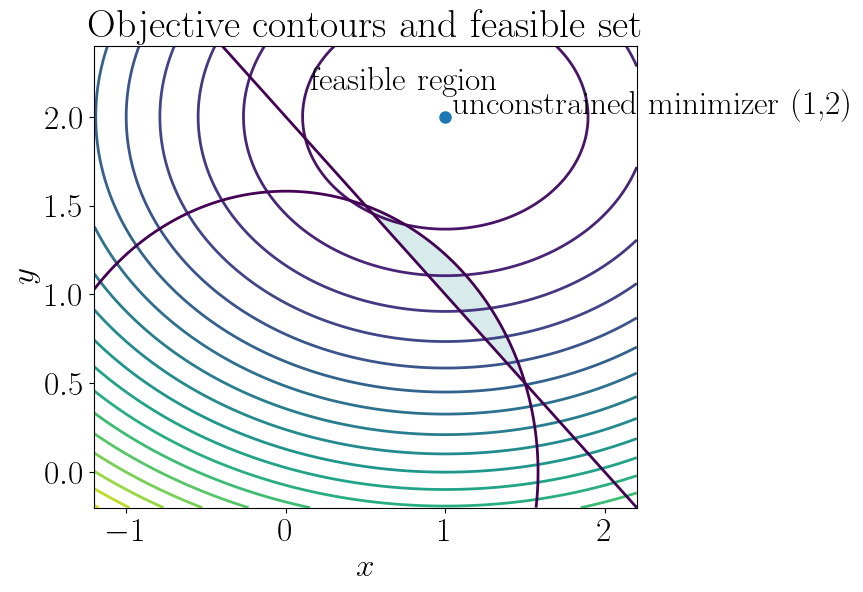

In [3]:

x = np.linspace(-1.2, 2.2, 401)
y = np.linspace(-0.2, 2.4, 401)
X, Y = np.meshgrid(x, y)

Z = (X - 1.0)**2 + 2.0*(Y - 2.0)**2
G1 = X + Y - 2.0
G2 = 2.5 - X**2 - Y**2
feasible = (G1 >= 0) & (G2 >= 0)

plt.figure()
plt.contour(X, Y, Z, levels=20)
plt.contourf(X, Y, feasible.astype(float), levels=[0.5, 1.5], alpha=0.18)
plt.contour(X, Y, G1, levels=[0], linewidths=2)
plt.contour(X, Y, G2, levels=[0], linewidths=2)

plt.text(0.15, 2.15, "feasible region")
plt.plot(1, 2, "o", markersize=8)
plt.text(1.05, 2.02, "unconstrained minimizer (1,2)")

plt.xlim(-1.2, 2.2)
plt.ylim(-0.2, 2.4)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Objective contours and feasible set")
plt.show()



The unconstrained minimizer is $(1,2)$, but it is **not feasible** because

$
1^2 + 2^2 = 5 > 2.5.
$

So the constraints matter.

This is the kind of setting where SQP is useful:
- the objective has curvature,
- the feasible set is nonlinear,
- and we need a principled way to move while respecting constraints.



## 5. One SQP-style step by hand

SciPy's `SLSQP` does not expose its internal quadratic subproblem directly.  
So to build intuition, we will create **one illustrative SQP step ourselves**.

Choose a current point $(1,2)$. Then build the local QP in the step $\mathbf{d}$:

$
\min_{\mathbf{d}}
\quad
\nabla f(\mathbf{x}_k)^T \mathbf{d}
+ \frac12 \mathbf{d}^T \nabla^2 f(\mathbf{x}_k)\mathbf{d}
$

subject to

$
g_i(\mathbf{x}_k) + \nabla g_i(\mathbf{x}_k)^T \mathbf{d} \ge 0.
$

Here we use the **true Hessian of the objective** just to keep the example simple.
In many SQP methods, $B_k$ is instead an approximation to the Hessian of the Lagrangian.


In [4]:

xk = np.array([0.2, 1.9])  # starting point

print("Current point xk =", xk)
print("f(xk) =", f(xk))
print("g1(xk) =", g1(xk))
print("g2(xk) =", g2(xk))


Current point xk = [0.2 1.9]
f(xk) = 0.6600000000000001
g1(xk) = 0.10000000000000009
g2(xk) = -1.15


In [5]:
# Solve the local QP in the step d using SciPy itself.
# This is for illustration only.

x0 = xk
Bk = hess_f(xk)
gfk = grad_f(xk)

def qp_obj(d):
    return gfk @ d + 0.5 * d @ Bk @ d

def qp_jac(d):
    return gfk + Bk @ d

qp_constraints = [
    {
        "type": "ineq",
        "fun": lambda d: g1(xk) + grad_g1(xk) @ d,
        "jac": lambda d: grad_g1(xk),
    },
    {
        "type": "ineq",
        "fun": lambda d: g2(xk) + grad_g2(xk) @ d,
        "jac": lambda d: grad_g2(xk),
    },
]

res_qp = minimize(
    qp_obj,
    x0=x0,
    jac=qp_jac,
    constraints=qp_constraints,
    method="SLSQP",
)

dk = res_qp.x
xtrial = xk + dk

print("QP step dk =", dk)
print("Trial point xk + dk =", xtrial)
print("QP solve success =", res_qp.success)


QP step dk = [ 0.699729   -0.37628726]
Trial point xk + dk = [0.899729   1.52371274]
QP solve success = True



Notice what just happened:

- We did **not** optimize the original nonlinear constrained problem directly.
- We optimized a **local quadratic approximation** with **linearized constraints**.
- The result is a candidate step.

That is the heart of SQP.


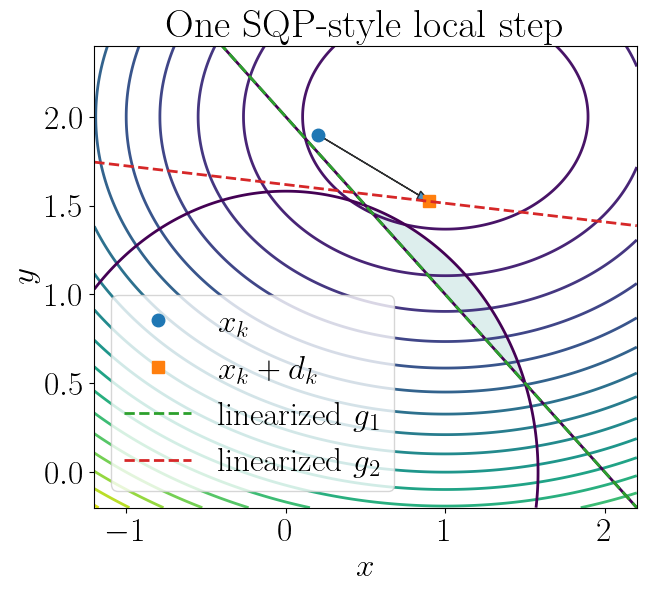

In [6]:

# Plot the current point, the SQP-style trial step, and the linearized constraints

plt.figure()
plt.contour(X, Y, Z, levels=20)
plt.contourf(X, Y, feasible.astype(float), levels=[0.5, 1.5], alpha=0.15)
plt.contour(X, Y, G1, levels=[0], linewidths=2)
plt.contour(X, Y, G2, levels=[0], linewidths=2)

# Current and trial points
plt.plot(xk[0], xk[1], "o", markersize=9, label="$x_k$")
plt.plot(xtrial[0], xtrial[1], "s", markersize=8, label="$x_k + d_k$")
plt.arrow(
    xk[0], xk[1], dk[0], dk[1],
    length_includes_head=True, head_width=0.05, alpha=0.8
)

# Linearized constraint boundaries
xx = np.linspace(-1.2, 2.2, 300)

# g1(xk) + grad_g1(xk)^T d = 0, with x = xk + d
# Equivalent to tangent line written in (x,y)-space through xk:
yy1 = 2.0 - xx
plt.plot(xx, yy1, "--", linewidth=2, label="linearized $g_1$")

# For g2, tangent line at xk:
# g2(xk) + grad_g2(xk)^T (x - xk) = 0
a, b = grad_g2(xk)
rhs = a * xk[0] + b * xk[1] - g2(xk)
yy2 = (rhs - a * xx) / b
plt.plot(xx, yy2, "--", linewidth=2, label="linearized $g_2$")

plt.xlim(-1.2, 2.2)
plt.ylim(-0.2, 2.4)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("One SQP-style local step")
plt.legend()
plt.show()


# Another step 

In [7]:
xk = xtrial
Bk = hess_f(xk)
gfk = grad_f(xk)

def qp_obj(d):
    return gfk @ d + 0.5 * d @ Bk @ d

def qp_jac(d):
    return gfk + Bk @ d

qp_constraints = [
    {
        "type": "ineq",
        "fun": lambda d: g1(xk) + grad_g1(xk) @ d,
        "jac": lambda d: grad_g1(xk),
    },
    {
        "type": "ineq",
        "fun": lambda d: g2(xk) + grad_g2(xk) @ d,
        "jac": lambda d: grad_g2(xk),
    },
]

res_qp = minimize(
    qp_obj,
    x0=xk,
    jac=qp_jac,
    constraints=qp_constraints,
    method="SLSQP",
)

dk = res_qp.x
xtrial = xk + dk

print("QP step dk =", dk)
print("Trial point xk + dk =", xtrial)
print("QP solve success =", res_qp.success)

QP step dk = [-0.41642915  0.03876518]
Trial point xk + dk = [0.48329984 1.56247792]
QP solve success = True


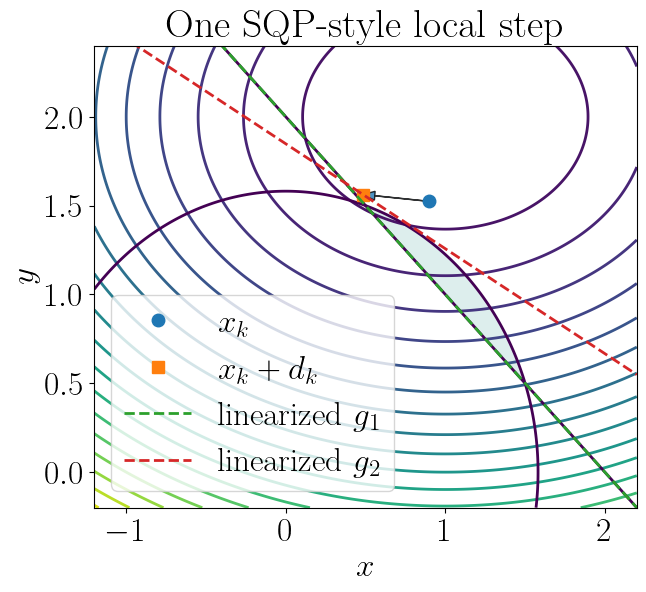

In [8]:

# Plot the current point, the SQP-style trial step, and the linearized constraints

plt.figure()
plt.contour(X, Y, Z, levels=20)
plt.contourf(X, Y, feasible.astype(float), levels=[0.5, 1.5], alpha=0.15)
plt.contour(X, Y, G1, levels=[0], linewidths=2)
plt.contour(X, Y, G2, levels=[0], linewidths=2)

# Current and trial points
plt.plot(xk[0], xk[1], "o", markersize=9, label="$x_k$")
plt.plot(xtrial[0], xtrial[1], "s", markersize=8, label="$x_k + d_k$")
plt.arrow(
    xk[0], xk[1], dk[0], dk[1],
    length_includes_head=True, head_width=0.05, alpha=0.8
)

# Linearized constraint boundaries
xx = np.linspace(-1.2, 2.2, 300)

# g1(xk) + grad_g1(xk)^T d = 0, with x = xk + d
# Equivalent to tangent line written in (x,y)-space through xk:
yy1 = 2.0 - xx
plt.plot(xx, yy1, "--", linewidth=2, label="linearized $g_1$")

# For g2, tangent line at xk:
# g2(xk) + grad_g2(xk)^T (x - xk) = 0
a, b = grad_g2(xk)
rhs = a * xk[0] + b * xk[1] - g2(xk)
yy2 = (rhs - a * xx) / b
plt.plot(xx, yy2, "--", linewidth=2, label="linearized $g_2$")

plt.xlim(-1.2, 2.2)
plt.ylim(-0.2, 2.4)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("One SQP-style local step")
plt.legend()
plt.show()


# Another step

QP step dk = [ 0.17745157 -0.11086256]
Trial point xk + dk = [0.66075141 1.45161535]
QP solve success = True


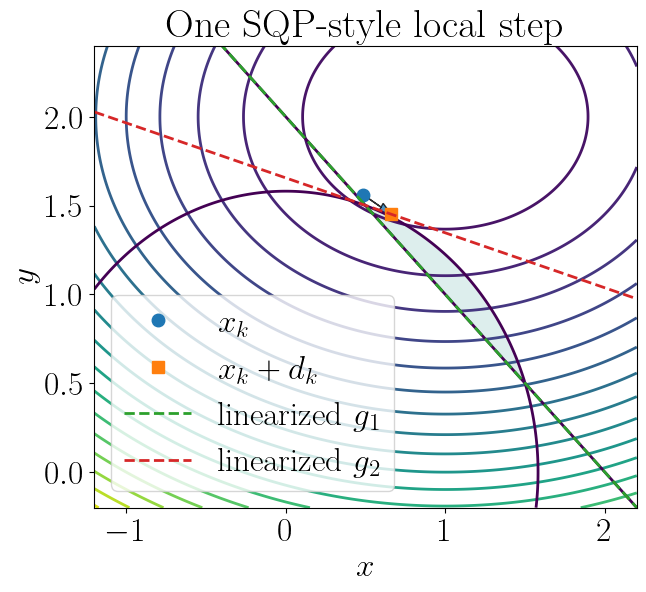

In [9]:
xk = xtrial
Bk = hess_f(xk)
gfk = grad_f(xk)

def qp_obj(d):
    return gfk @ d + 0.5 * d @ Bk @ d

def qp_jac(d):
    return gfk + Bk @ d

qp_constraints = [
    {
        "type": "ineq",
        "fun": lambda d: g1(xk) + grad_g1(xk) @ d,
        "jac": lambda d: grad_g1(xk),
    },
    {
        "type": "ineq",
        "fun": lambda d: g2(xk) + grad_g2(xk) @ d,
        "jac": lambda d: grad_g2(xk),
    },
]

res_qp = minimize(
    qp_obj,
    x0=xk,
    jac=qp_jac,
    constraints=qp_constraints,
    method="SLSQP",
)

dk = res_qp.x
xtrial = xk + dk

print("QP step dk =", dk)
print("Trial point xk + dk =", xtrial)
print("QP solve success =", res_qp.success)


# Plot the current point, the SQP-style trial step, and the linearized constraints

plt.figure()
plt.contour(X, Y, Z, levels=20)
plt.contourf(X, Y, feasible.astype(float), levels=[0.5, 1.5], alpha=0.15)
plt.contour(X, Y, G1, levels=[0], linewidths=2)
plt.contour(X, Y, G2, levels=[0], linewidths=2)

# Current and trial points
plt.plot(xk[0], xk[1], "o", markersize=9, label="$x_k$")
plt.plot(xtrial[0], xtrial[1], "s", markersize=8, label="$x_k + d_k$")
plt.arrow(
    xk[0], xk[1], dk[0], dk[1],
    length_includes_head=True, head_width=0.05, alpha=0.8
)

# Linearized constraint boundaries
xx = np.linspace(-1.2, 2.2, 300)

# g1(xk) + grad_g1(xk)^T d = 0, with x = xk + d
# Equivalent to tangent line written in (x,y)-space through xk:
yy1 = 2.0 - xx
plt.plot(xx, yy1, "--", linewidth=2, label="linearized $g_1$")

# For g2, tangent line at xk:
# g2(xk) + grad_g2(xk)^T (x - xk) = 0
a, b = grad_g2(xk)
rhs = a * xk[0] + b * xk[1] - g2(xk)
yy2 = (rhs - a * xx) / b
plt.plot(xx, yy2, "--", linewidth=2, label="linearized $g_2$")

plt.xlim(-1.2, 2.2)
plt.ylim(-0.2, 2.4)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("One SQP-style local step")
plt.legend()
plt.show()



## 6. Now solve the full nonlinear problem with SciPy SLSQP

We now let SciPy handle the entire constrained optimization problem.

To make the path visible, we will record every iterate through a callback.


In [10]:
history = []

def callback(xk):
    history.append(np.copy(xk))

x0 = np.array([0.2, 1.9])
history.append(np.copy(x0))

res = minimize(
    f,
    x0=x0,
    jac=grad_f,
    constraints=constraints,
    method="SLSQP",
    callback=callback,
    options={"ftol": 1e-9, "disp": True, "maxiter": 100},
)

xstar = res.x

print("Success:", res.success)
print("Message:", res.message)
print("x* =", xstar)
print("f(x*) =", res.fun)
print("g1(x*) =", g1(xstar))
print("g2(x*) =", g2(xstar))


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.7362518166209591
            Iterations: 8
            Function evaluations: 10
            Gradient evaluations: 8
Success: True
Message: Optimization terminated successfully
x* = [0.58128451 1.47041094]
f(x*) = 0.7362518166209591
g1(x*) = 0.0516954441765467
g2(x*) = -5.728750807065808e-14


In [11]:
history

[array([0.2, 1.9]),
 array([1.70931507, 1.43849315]),
 array([0.6111458, 1.4865515]),
 array([0.5762697 , 1.49194016]),
 array([0.58766624, 1.46810972]),
 array([0.58089057, 1.4705843 ]),
 array([0.58128475, 1.47041091]),
 array([0.58128451, 1.47041094]),
 array([0.58128451, 1.47041094])]


## Take-home summary

The simplest way to remember SQP is this:

> At the current point, replace the nonlinear constrained problem by a quadratic program, solve that QP, move, and repeat.

More concretely:

- **quadratic** model for the objective,
- **linearized** constraints,
- **iterative** updates,
- and in SciPy, the practical method to try is **SLSQP**.
